<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h1>Metaparameters</h1>
<p>Parameters (mainly weights and bias) are the params that the model learns during training.<br>Metaparameters are the ones not learned, but set by the developer. Examples include model architecture, number of hidden layers, number of units per layer, cross validation sizes, mini-batch size, activation functions, optimization functions, learning rate, dropout, loss function, data normalization, weight normalization, weight initialization, ... etc.</p>

<p>It is practically impossible to search through th entire metaparameter space, so it is impossible to know whether we are using the best settings.</p>

<h2>The wine quality dataset</h2>
</div>

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

import time

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

data = pd.read_csv(url, sep=';')
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [3]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [4]:
for key in data.keys():
    print(f'{key} has {np.shape(np.unique(data[key]))[0]} unique values')

fixed acidity has 96 unique values
volatile acidity has 143 unique values
citric acid has 80 unique values
residual sugar has 91 unique values
chlorides has 153 unique values
free sulfur dioxide has 60 unique values
total sulfur dioxide has 144 unique values
density has 436 unique values
pH has 89 unique values
sulphates has 96 unique values
alcohol has 65 unique values
quality has 6 unique values


C:\Users\szala\AppData\Local\Temp\ipykernel_13332\2827752846.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


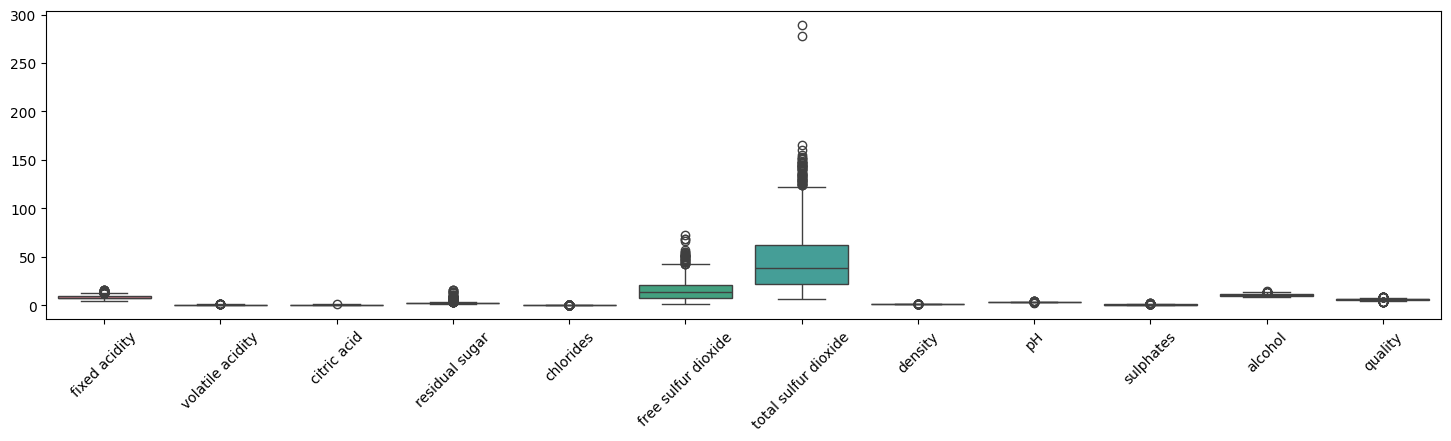

In [5]:
fig, ax = plt.subplots(1, figsize=(18, 4))
ax = sns.boxplot(data=data)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.show()

<link rel="stylesheet" href="../../styles.css">
<div class="note">
<p>Outliers can detriment the model quality, so we remove them.<br>The different scale of the data columns can also become a problem, so we z-score the columns.</p>
</div>

C:\Users\szala\AppData\Local\Temp\ipykernel_13332\150456138.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


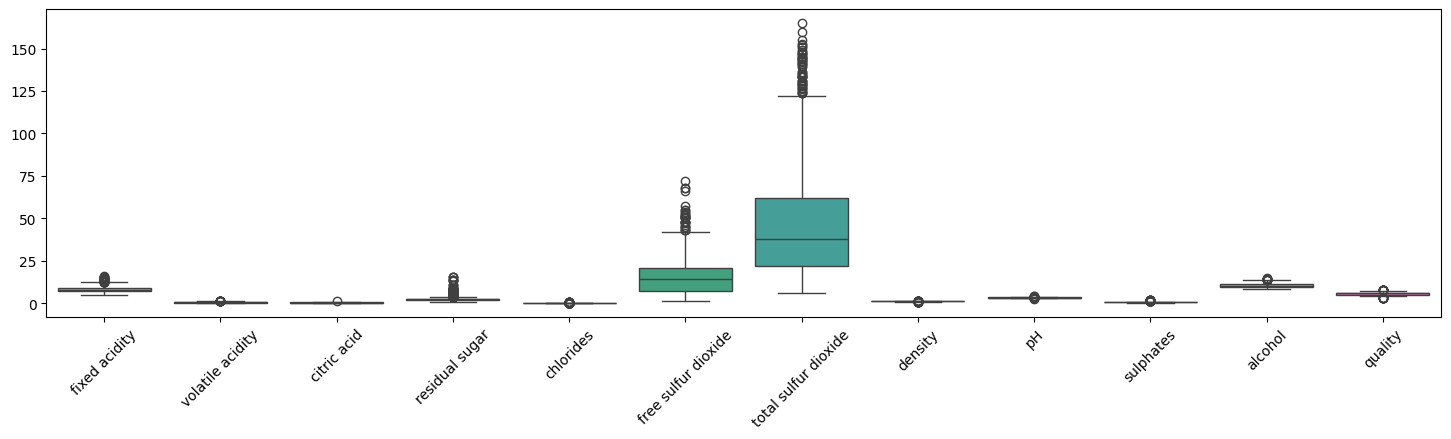

In [6]:
# outlier removal
data = data[data['total sulfur dioxide'] < 200]
fig, ax = plt.subplots(1, figsize=(18, 4))
ax = sns.boxplot(data=data)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.show()

In [7]:
# z-score
columnsToZscore = data.keys()
columnsToZscore = columnsToZscore.drop('quality')

for column in columnsToZscore:
    mean = np.mean(data[column])
    std = np.std(data[column], ddof=1)
    data[column] = (data[column] - mean) / std
# alternatively: data[columnsToZscore].apply(stats.zscore)

C:\Users\szala\AppData\Local\Temp\ipykernel_13332\2827752846.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


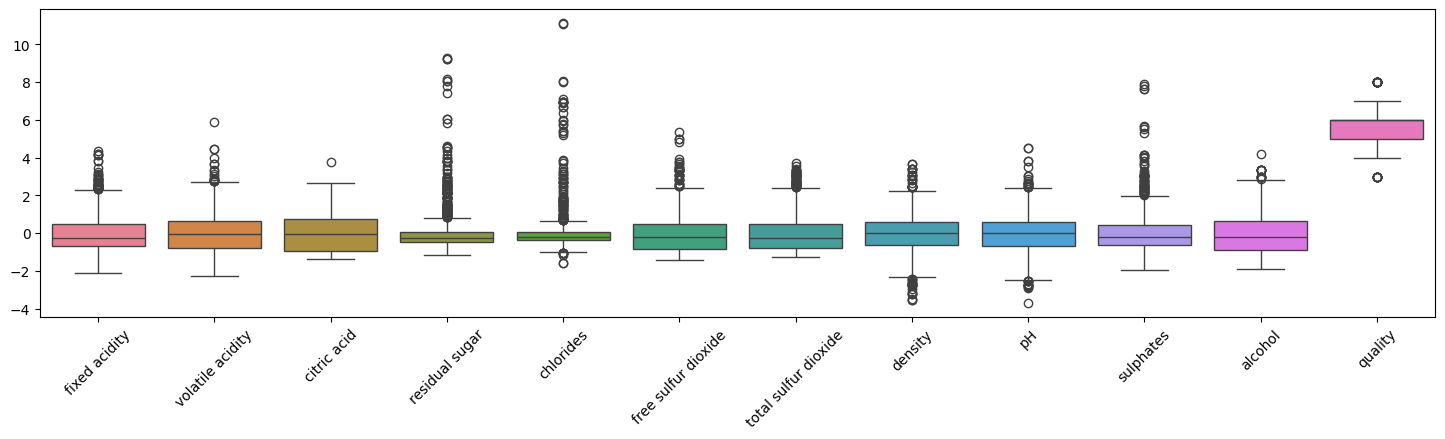

In [8]:
fig, ax = plt.subplots(1, figsize=(18, 4))
ax = sns.boxplot(data=data)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.show()

In [9]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1597.000000
mean,1.779694e-17,1.156801e-16,1.779694e-17,-7.563699e-17,-1.512740e-16,-1.779694e-17,-7.118775e-17,-8.357442e-14,3.025479e-16,8.008622e-17,-5.872989e-16,5.634314
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.806630
min,-2.135419e+00,-2.280048e+00,-1.391387e+00,-1.168783e+00,-1.604073e+00,-1.422392e+00,-1.262186e+00,-3.545821e+00,-3.708218e+00,-1.936711e+00,-1.898626e+00,3.000000
25%,-7.003882e-01,-7.715838e-01,-9.283861e-01,-4.524372e-01,-3.720247e-01,-8.476045e-01,-7.594598e-01,-6.109478e-01,-6.585382e-01,-6.390204e-01,-8.650444e-01,5.000000
50%,-2.411785e-01,-4.528645e-02,-5.382836e-02,-2.375335e-01,-1.808448e-01,-1.770192e-01,-2.567340e-01,-6.214425e-04,-9.670044e-03,-2.261189e-01,-2.073106e-01,6.000000
75%,5.050372e-01,6.251419e-01,7.692848e-01,4.900487e-02,5.281955e-02,4.935662e-01,4.973546e-01,5.778618e-01,5.743113e-01,4.227263e-01,6.383472e-01,6.000000
max,4.350918e+00,5.876831e+00,3.753070e+00,9.289866e+00,1.112001e+01,5.379259e+00,3.733652e+00,3.682565e+00,4.532407e+00,7.913939e+00,4.208902e+00,8.000000


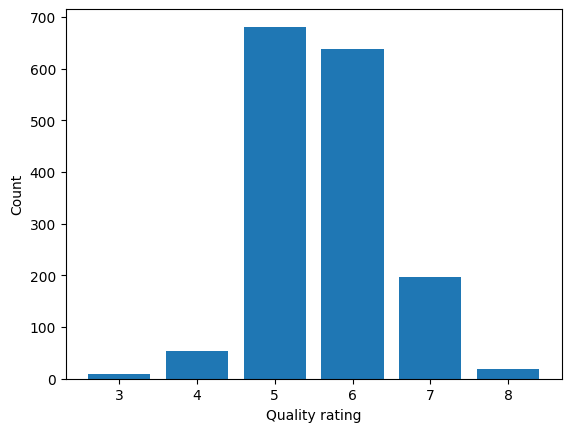

In [10]:
qualityCounts = data['quality'].value_counts()
keys = list(qualityCounts.keys())
values = list(qualityCounts)

plt.bar(keys, values)
plt.xlabel('Quality rating')
plt.ylabel('Count')
plt.show()

<link rel="stylesheet" href="../../styles.css">
<div class="note">
<p>Usually it is desirable for the dependent variable (quality) to have roughly the same number of data points in each value. We can do it by having a new column called boolQuality.</p>
</div>

In [11]:
data['boolQuality'] = data['quality'] > 5
print(f'Number of good quality wines: {np.shape(data[data['boolQuality'] == True])[0]}')
print(f'Number of poor quality wines: {np.shape(data[data['boolQuality'] == False])[0]}')
data

Number of good quality wines: 853
Number of poor quality wines: 744


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,boolQuality
0,-0.528185,0.960356,-1.391387,-0.452437,-0.244571,-0.464413,-0.382415,0.556633,1.288066,-0.580034,-0.959006,5,False
1,-0.298580,1.965999,-1.391387,0.049005,0.222757,0.876758,0.654456,0.025914,-0.723425,0.127797,-0.583159,5,False
2,-0.298580,1.295570,-1.185609,-0.165899,0.095304,-0.081221,0.245992,0.132058,-0.334104,-0.049161,-0.583159,5,False
3,1.653061,-1.386143,1.489509,-0.452437,-0.265814,0.110375,0.434514,0.662777,-0.982972,-0.462063,-0.583159,6,True
4,-0.528185,0.960356,-1.391387,-0.452437,-0.244571,-0.464413,-0.382415,0.556633,1.288066,-0.580034,-0.959006,5,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,-1.216999,0.401666,-0.979831,-0.380803,0.052820,1.547343,-0.068212,-0.982451,0.898745,-0.462063,0.074575,5,False
1595,-1.389203,0.122321,-0.876942,-0.237533,-0.541962,2.217928,0.151731,-0.865693,1.352953,0.599684,0.732309,6,True
1596,-1.159598,-0.101155,-0.722608,-0.165899,-0.244571,1.259949,-0.193893,-0.536647,0.704085,0.540698,0.544385,6,True
1597,-1.389203,0.653076,-0.774052,-0.380803,-0.265814,1.547343,-0.068212,-0.679941,1.677387,0.304754,-0.207311,5,False


In [12]:
dataTensor = torch.tensor(data[columnsToZscore].values).float()
labels = torch.tensor(data['boolQuality'].values).float()
print(dataTensor.shape)
print(labels.shape)

labels = labels[:,None]
print(labels.shape)

torch.Size([1597, 11])
torch.Size([1597])
torch.Size([1597, 1])


In [13]:
trainData, testData, trainLabels, testLabels = train_test_split(dataTensor, labels, test_size=.2)

trainData = TensorDataset(trainData, trainLabels)
testData = TensorDataset(testData, testLabels)

In [14]:
class ANNwine(nn.Module):
    def __init__(self):
        super().__init__()

        self.input = nn.Linear(11, 16)
        self.hiddenLayers = [
            nn.Linear(16, 32),
            nn.Linear(32, 32)
        ]
        self.output = nn.Linear(32, 1)
    
    def forward(self, x):
        x = F.relu(self.input(x))
        for hidden in self.hiddenLayers:
            x = F.relu(hidden(x))
        return self.output(x)

def trainModel(model: ANNwine, trainingData: TensorDataset, testingData: TensorDataset, numberOfEpochs: int, batchSize: int):
    lossFunction = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

    losses = torch.zeros(numberOfEpochs)
    trainAccuracy = []
    testAccuracy = []

    trainLoader = DataLoader(trainingData, batch_size=batchSize, shuffle=True)
    testLoader = DataLoader(testingData, batch_size=testData.tensors[0].shape[0])

    index = 0
    for i in range(numberOfEpochs):
        model.train()
        batchAccuracy = []
        batchLoss = []

        for x,y in trainLoader:
            yHat = model(x)

            loss = lossFunction(yHat, y)
            batchLoss.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batchAccuracy.append(100*torch.mean(((yHat>0) == y).float()).item())
        trainAccuracy.append(np.mean(batchAccuracy))
        losses[index] = np.mean(batchLoss)
        index += 1

        model.eval()
        x,y = next(iter(testLoader))
        with torch.no_grad():
            yHat = model(x)
        testAccuracy.append(100*torch.mean(((yHat>0) == y).float()).item())
    
    return losses, trainAccuracy, testAccuracy

In [15]:
numberOfEpochs = 1_000
batchSizes = 2**np.arange(3, 10, 2)

trainingResults = np.zeros((numberOfEpochs, np.shape(batchSizes)[0]))
testingResults = np.zeros((numberOfEpochs, np.shape(batchSizes)[0]))
trainingTime = np.zeros(np.shape(batchSizes)[0])

index = 0
for batchSize in batchSizes:
    print(f'Running experiment with batch size {batchSize}')
    model = ANNwine()

    startTime = time.process_time()
    losses, trainingAccuracy, testAccuracy = trainModel(model, trainingData=trainData, testingData=testData, numberOfEpochs=numberOfEpochs, batchSize=int(batchSize))

    trainingTime[index] = time.process_time() - startTime
    trainingResults[:,index] = trainingAccuracy
    testingResults[:,index] = testAccuracy
    index += 1

Running experiment with batch size 8
Running experiment with batch size 32
Running experiment with batch size 128
Running experiment with batch size 512


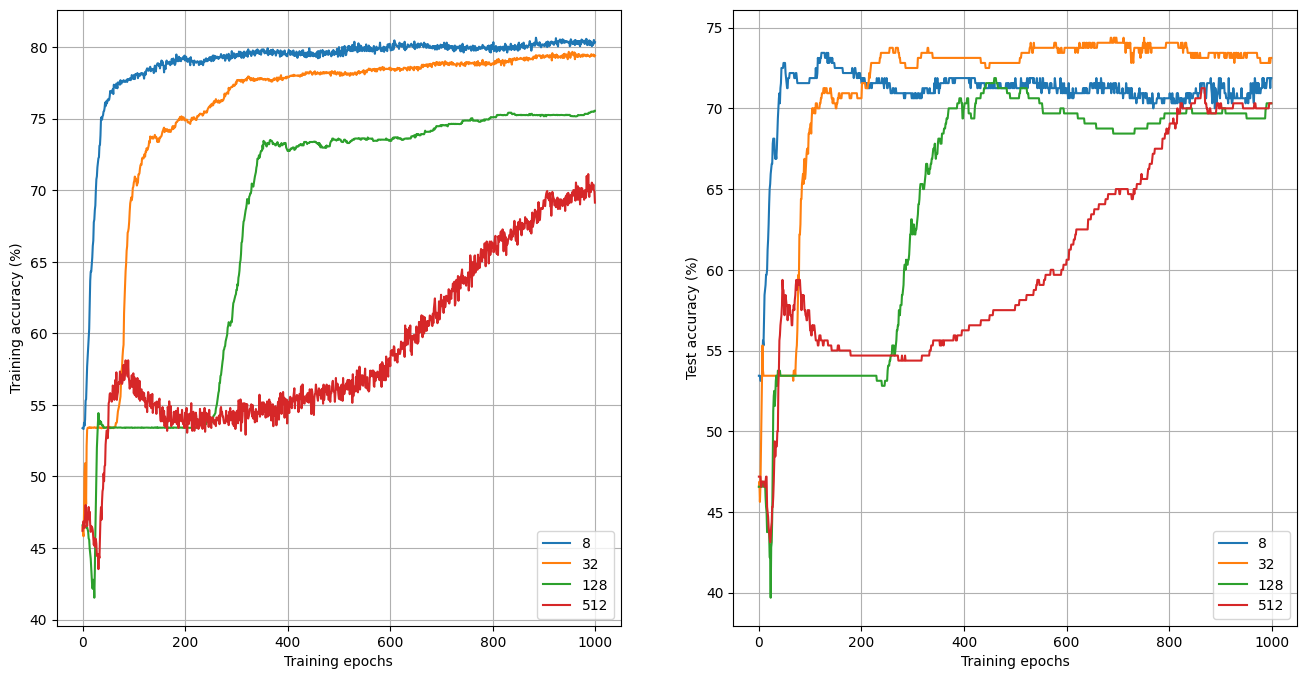

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].plot(trainingResults)
ax[0].grid()
ax[0].set_xlabel('Training epochs')
ax[0].set_ylabel('Training accuracy (%)')
ax[0].legend(batchSizes)

ax[1].plot(testingResults)
ax[1].grid()
ax[1].set_xlabel('Training epochs')
ax[1].set_ylabel('Test accuracy (%)')
ax[1].legend(batchSizes)


plt.show()

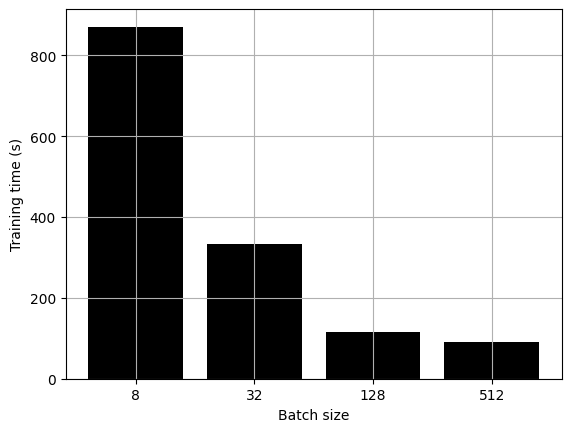

In [17]:
plt.bar(range(len(batchSizes)), trainingTime, color='black')
plt.xlabel('Batch size')
plt.ylabel('Training time (s)')
plt.xticks([0, 1, 2, 3], batchSizes)
plt.grid()
plt.show()

<link rel="stylesheet" href="../../styles.css">
<div class="note">
<p>Small batch sizes tend to result in quick learning but with a risk of overfitting (much larger training accuracy than testing accuracy).</p>
</div>

<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h2>Data normalization</h2>
<p>Not normalized input data can result in huge differences of the losses between data points. Large data can dominate the training while small number datapoints will have less saying in the setting of params.<br>To avoid this, we should make sure that the input data are roghly the same range.</p>
<p>Common normalization methods: 
<ul>
<li>Z-transform: The units are standard deviations away from the mean of the distribution

$$ z_i = \frac{x_i - \overline{x}}{\sigma_x} $$

</li>
<li>Min-max scaling: Transforming the data in a way that the smallest data point becomes 0 and the largest becomes 1.

$$ \widetilde{x} = \frac{x - min(x)}{max(x) - min(x)} $$

</li>
</ul>
</p>
<p>Min-max scaling is more common for data that is bounded, like the RGB values of pixels in an image.</p>
<h2>Batch normalization</h2>
<p>Barch normalization refers to the practice of using a learnt mean/variance for data normalization instead of the empirical values.

$$ \widetilde{x} = \gamma x + \beta \\
y = \sigma(\widetilde{x}^Tw) $$

Beta and gamma are parameters learnt by the model, it takes place before the activation. Batch normalization is switched off for testing (after model.eval()).
</p>
</div>

In [18]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

data = pd.read_csv(url, sep=';')
data = data[data['total sulfur dioxide'] < 200]

columnsToZscore = data.keys()
columnsToZscore = columnsToZscore.drop('quality')
data[columnsToZscore] = data[columnsToZscore].apply(stats.zscore)
data['boolQuality'] = 0
data.loc[data['quality'] > 5, 'boolQuality'] = 1
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,boolQuality
0,-0.528350,0.960657,-1.391823,-0.452579,-0.244648,-0.464558,-0.382535,0.556807,1.288470,-0.580216,-0.959307,5,0
1,-0.298673,1.966614,-1.391823,0.049020,0.222827,0.877032,0.654661,0.025923,-0.723652,0.127837,-0.583341,5,0
2,-0.298673,1.295976,-1.185980,-0.165951,0.095334,-0.081247,0.246069,0.132100,-0.334209,-0.049176,-0.583341,5,0
3,1.653579,-1.386577,1.489975,-0.452579,-0.265897,0.110409,0.434650,0.662984,-0.983280,-0.462207,-0.583341,6,1
4,-0.528350,0.960657,-1.391823,-0.452579,-0.244648,-0.464558,-0.382535,0.556807,1.288470,-0.580216,-0.959307,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,-1.217380,0.401792,-0.980138,-0.380922,0.052836,1.547828,-0.068233,-0.982759,0.899027,-0.462207,0.074599,5,0
1595,-1.389638,0.122359,-0.877216,-0.237608,-0.542132,2.218623,0.151778,-0.865964,1.353377,0.599872,0.732539,6,1
1596,-1.159961,-0.101187,-0.722834,-0.165951,-0.244648,1.260344,-0.193954,-0.536815,0.704305,0.540868,0.544556,6,1
1597,-1.389638,0.653281,-0.774295,-0.380922,-0.265897,1.547828,-0.068233,-0.680154,1.677912,0.304850,-0.207376,5,0


In [19]:
dataTensor = torch.tensor(data[columnsToZscore].values).float()
labels = torch.tensor(data['boolQuality'].values).float()[:,None]

trainData, testData, trainLabels, testLabels = train_test_split(dataTensor, labels, test_size=0.2)

trainData = TensorDataset(trainData, trainLabels)
testData = TensorDataset(testData, testLabels)

trainLoader = DataLoader(trainData, batch_size=16, shuffle=True, drop_last=True)
testLoader = DataLoader(testData, batch_size=testData.tensors[0].shape[0])

In [20]:
class ANNwineWithBatchNorm(nn.Module):

    def __init__(self):
        super().__init__()
        self.input = nn.Linear(11, 16)

        self.hiddenLayers = [
            nn.Linear(16, 32),
            nn.Linear(32, 20)
        ]

        self.batchNormalizers = [
            nn.BatchNorm1d(16),
            nn.BatchNorm1d(32)
        ]
        self.output = nn.Linear(20, 1)
    
    def forward(self, x, doBatchNormalization: bool):
        x = F.relu(self.input(x))

        for i in range(len(self.hiddenLayers)):
            if doBatchNormalization:
                x = self.batchNormalizers[i](x)
            x = self.hiddenLayers[i](x)
            x = F.relu(x)
        
        return self.output(x)

def trainModel(model: ANNwineWithBatchNorm, trainingData: TensorDataset, testingData: TensorDataset, numberOfEpochs: int, batchSize: int, batchNorm: bool):
    lossFunction = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

    losses = torch.zeros(numberOfEpochs)
    trainAccuracy = []
    testAccuracy = []

    trainLoader = DataLoader(trainingData, batch_size=batchSize, shuffle=True)
    testLoader = DataLoader(testingData, batch_size=testData.tensors[0].shape[0])

    index = 0
    for i in range(numberOfEpochs):
        model.train()
        batchAccuracy = []
        batchLoss = []

        for x,y in trainLoader:
            yHat = model(x, batchNorm)

            loss = lossFunction(yHat, y)
            batchLoss.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batchAccuracy.append(100*torch.mean(((yHat>0) == y).float()).item())
        trainAccuracy.append(np.mean(batchAccuracy))
        losses[index] = np.mean(batchLoss)
        index += 1

        model.eval()
        x,y = next(iter(testLoader))
        with torch.no_grad():
            yHat = model(x, batchNorm)
        testAccuracy.append(100*torch.mean(((yHat>0) == y).float()).item())
    
    return losses, trainAccuracy, testAccuracy

In [21]:
model = ANNwineWithBatchNorm()
lossesWithout, trainAccWithout, testAccWithout = trainModel(model, trainData, testData, 1_000, 32, False)

model = ANNwineWithBatchNorm()
lossesWith, trainAccWith, testAccWith = trainModel(model, trainData, testData, 1_000, 32, True)

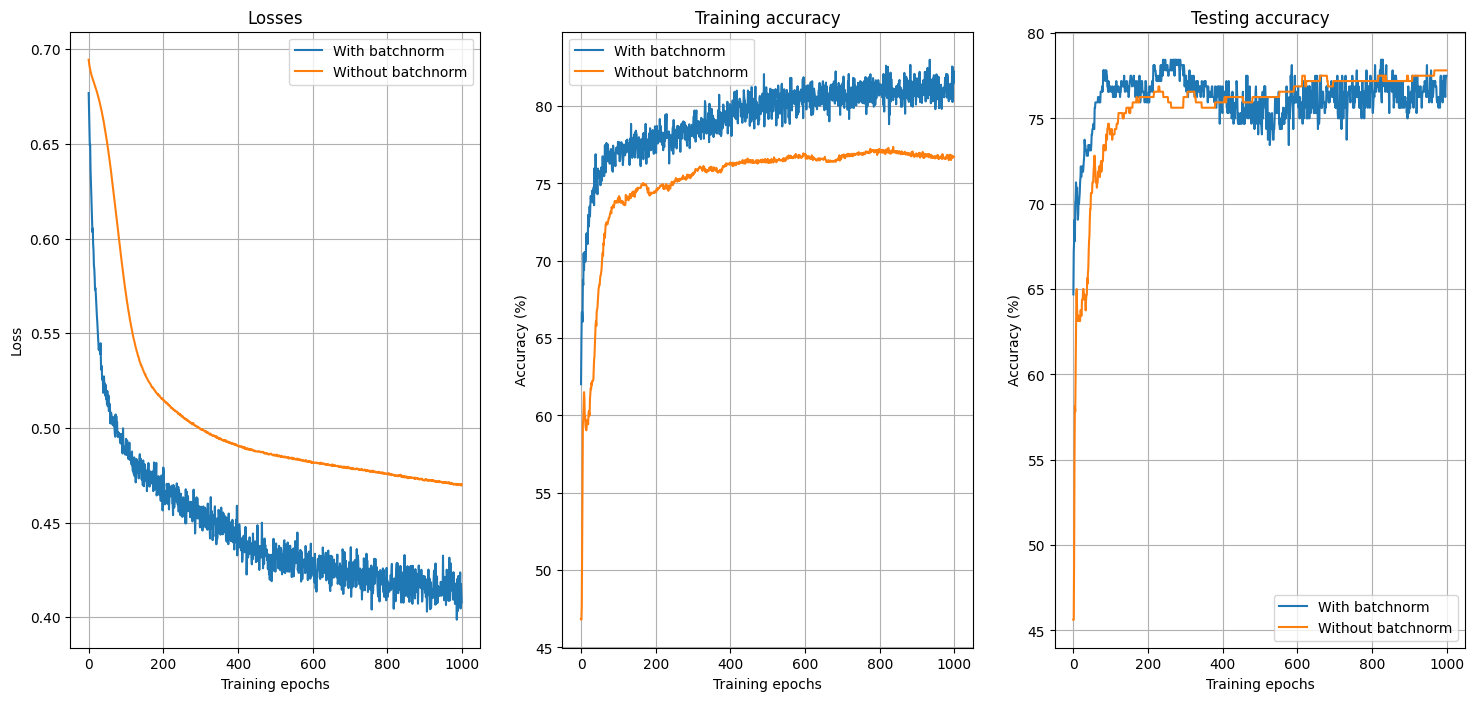

In [22]:
fig, ax = plt.subplots(1, 3, figsize=(18,8))

ax[0].plot(lossesWith, label='With batchnorm')
ax[0].plot(lossesWithout, label='Without batchnorm')
ax[0].legend()
ax[0].set_xlabel('Training epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Losses')
ax[0].grid()

ax[1].plot(trainAccWith, label='With batchnorm')
ax[1].plot(trainAccWithout, label='Without batchnorm')
ax[1].legend()
ax[1].set_xlabel('Training epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title('Training accuracy')
ax[1].grid()

ax[2].plot(testAccWith, label='With batchnorm')
ax[2].plot(testAccWithout, label='Without batchnorm')
ax[2].legend()
ax[2].set_xlabel('Training epochs')
ax[2].set_ylabel('Accuracy (%)')
ax[2].set_title('Testing accuracy')
ax[2].grid()

plt.show()

<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h2>Activation functions</h2>
<p>Any purely linear model (no non-linearity caused by activation functions) is basically a single layer.<br>It is desired that an activation function is: <ul>
<li>Non-linear</li>
<li>Computationally simple</li>
<li>Non-limited range (for output layer limited range can be good if we want to output a probability)</li>
<li>Avoid vanishing/exploding gradient</li>
</ul></p>

<p>Commonly used activation functions:<ul>
<li>Sigmoid: Saturates at [0, 1]. Good for output layer, not great for hidden layer.

$$ \sigma(x) = \frac {1}{1 + e^{-x}} $$

<img src="../../assets/dudl-06-sigmoid.png">

</li>
<li>Hyperbolic tangent: Saturates at [-1, 1]

$$ \sigma(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} $$

<img src="../../assets/dudl-06-hyperbol-tang.png">

</li>
<li>ReLU: Best for hidden layers.

$$ \sigma(x) = max(0, x) $$

<img src="../../assets/dudl-06-relu.png">

</li>
</ul></p>
</div>

In [23]:
x = torch.linspace(-3, 3, 1_001)
print(x)

def activate(functionName, x):
    return getattr(torch, functionName)(x)

tensor([-3.0000, -2.9940, -2.9880,  ...,  2.9880,  2.9940,  3.0000])


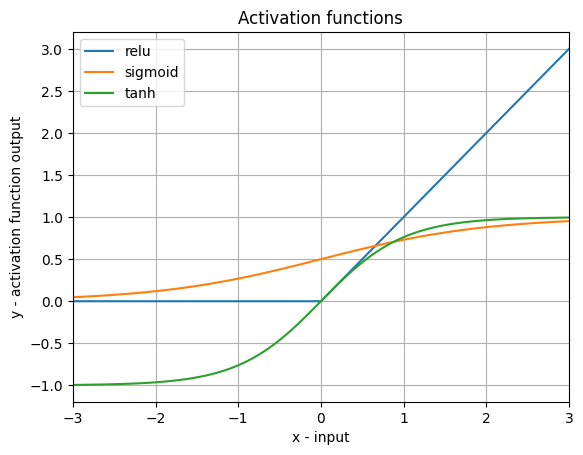

In [24]:
activationFunctions = ['relu', 'sigmoid', 'tanh']

for act in activationFunctions:
    plt.plot(x, activate(act, x))
    plt.xlim([-3, 3])
    plt.grid()
    plt.xlabel('x - input')
    plt.ylabel('y - activation function output')
    plt.title('Activation functions')

plt.legend(activationFunctions)
plt.show()

<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h2>Loss functions</h2>
<p>In general, two types. One for continuous data, one for categorical. Most common are MSE (Mean-Squared Error) and CE (Cross-Entropy Loss).</p>
<p>If we have one output with linear activation function, MSE is the most common.<br>If we have one output and sigmoid activation function BCE (Binary Cross-Entropy) is the most common.<br>For multiple output and softmax activation function, we should use CCE (Categorical Cross-Entropy).</p>

<p>Softmax with two categories is a sigmoid. For only two categories we should use sigmoid because simplifies the calculations, but for more categories it is not suitable, because it does not create a probability distribution, only for two categories.</p>

<p>For small values to work-around the computer's rounding errors we should prefer log-softmax instead of softmax. It penalizes mistakes harder than plain softmax.</p>
</div>

In [25]:
def plotLoss(lossFunctionName: str, y: float, yHatLims: list):
    lossFunction = getattr(nn, lossFunctionName)()
    size = int(1 + (yHatLims[1] - yHatLims[0])*100)
    yHat = torch.linspace(yHatLims[0], yHatLims[1], size)
    y = torch.tensor(y)
    losses = np.zeros(size)

    for index,yHatValue in enumerate(yHat):
        losses[index] = lossFunction(yHatValue, y)
    
    plt.plot(yHat, losses)
    plt.plot(y, lossFunction(y, y), 'rx')
    plt.xlabel(r'$\hat{y}$')
    plt.ylabel('Loss')
    plt.title(lossFunctionName)
    plt.grid()
    plt.xlim([yHatLims[0], yHatLims[1]])
    plt.legend([r'Loss as a function of $\hat{y}$', 'y'])
    plt.show()

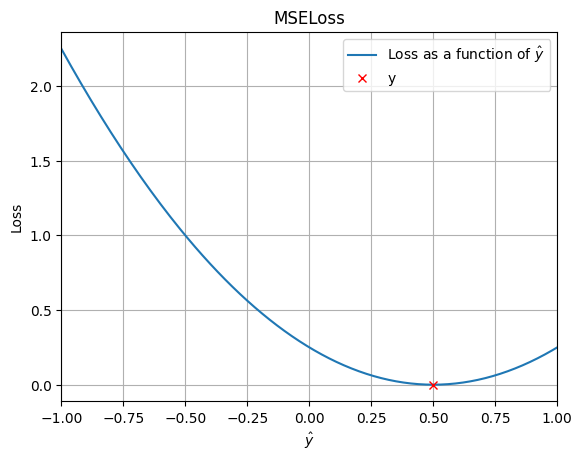

In [26]:
plotLoss('MSELoss', y=0.5, yHatLims=[-1, 1])

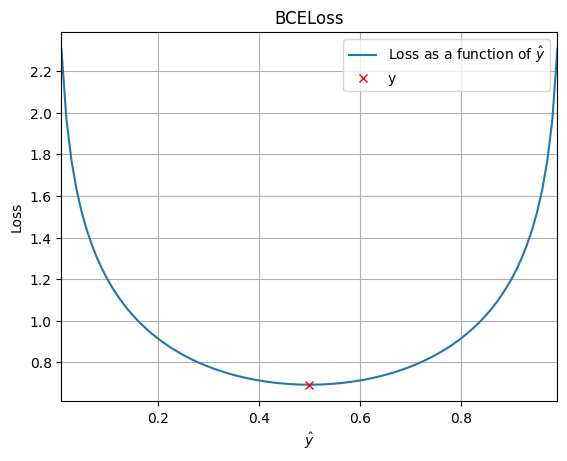

In [27]:
plotLoss('BCELoss', y=0.5, yHatLims=[0.01, 0.99])

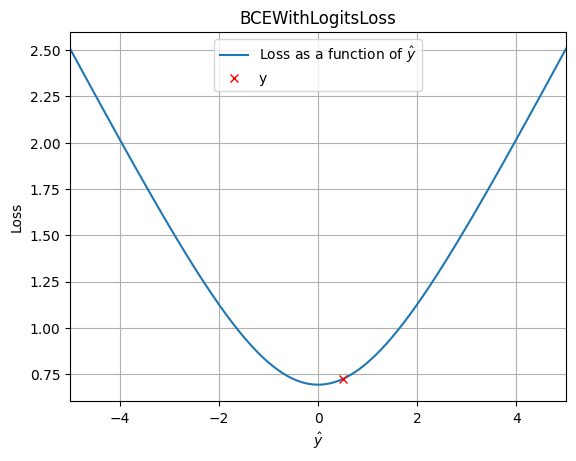

In [28]:
plotLoss('BCEWithLogitsLoss', y=0.50, yHatLims=[-5, 5])

In [29]:
# Creating your own loss function example:
class MyLoss(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, x, y):
        return torch.abs(x -y)

print(MyLoss()(torch.tensor(5), torch.tensor(3)))

tensor(2)


<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h2>Multiple output practice</h2>
</div>

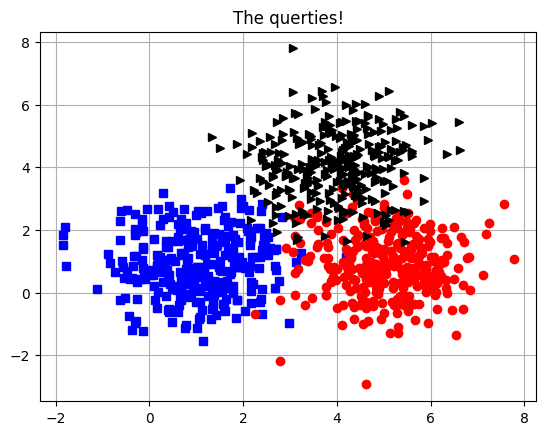

In [30]:
nPerClust = 300
blur = 1

A = [1, 1]
B = [5, 1]
C = [4, 4]

a = [A[0] + np.random.randn(nPerClust)*blur, A[1] + np.random.randn(nPerClust)*blur]
b = [B[0] + np.random.randn(nPerClust)*blur, B[1] + np.random.randn(nPerClust)*blur]
c = [C[0] + np.random.randn(nPerClust)*blur, C[1] + np.random.randn(nPerClust)*blur]

labelsNp = np.hstack((np.zeros(nPerClust), np.ones(nPerClust), 2*np.ones(nPerClust)))

data = torch.tensor(np.hstack((a, b, c)).T).float()
labels = torch.tensor(labelsNp).long()

plt.plot(data[np.where(labels == 0)][:,0], data[np.where(labels == 0)][:,1], 'bs')
plt.plot(data[np.where(labels == 1)][:,0], data[np.where(labels == 1)][:,1], 'ro')
plt.plot(data[np.where(labels == 2)][:,0], data[np.where(labels == 2)][:,1], 'k>')
plt.grid()
plt.title('The querties!')
plt.show()

In [31]:
trainData, testData, trainLabels, testLabels = train_test_split(data, labels, test_size=0.25)

trainData = TensorDataset(trainData, trainLabels)
testData = TensorDataset(testData, testLabels)

trainLoader = DataLoader(trainData, shuffle=True, batch_size=16, drop_last=True)
testLoader = DataLoader(testData, batch_size=testData.tensors[0].shape[0])

In [32]:
class quertyNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.input = nn.Linear(2, 4)

        self.hiddenLayers = [
            nn.Linear(4, 8),
            nn.Linear(8, 4)
        ]

        self.output = nn.Linear(4, 3)
    
    def forward(self, x):
        x = F.relu(self.input(x))
        for layer in self.hiddenLayers:
            x = F.relu(layer(x))
        return self.output(x)

Starting training epoch 0
Starting training epoch 100
Starting training epoch 200
Starting training epoch 300
Starting training epoch 400
Starting training epoch 500
Starting training epoch 600
Starting training epoch 700
Starting training epoch 800
Starting training epoch 900


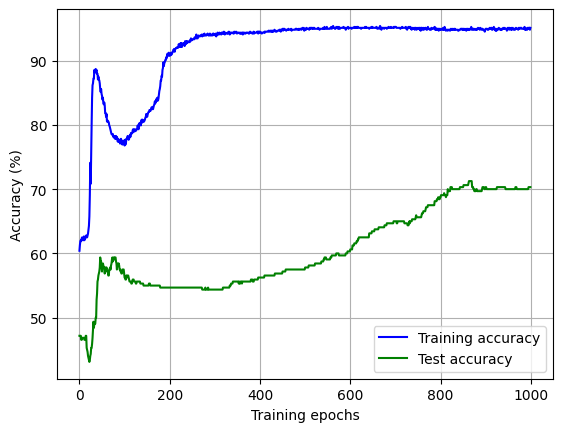

In [33]:
model = quertyNet()

numberOfEpochs = 1_000
lossFunction = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=.01)

trainingAccuracy = np.zeros(numberOfEpochs)
testingAccuracy = np.zeros(numberOfEpochs)

for epoch in range(numberOfEpochs):
    if epoch % 100 == 0:
        print(f'Starting training epoch {epoch}')

    model.train()
    batchAccuracy = []

    for x,y in trainLoader:
        yHat = model(x)

        loss = lossFunction(yHat, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batchAccuracy.append(100*torch.mean((torch.argmax(yHat, axis=1) == y).float()))
    trainingAccuracy[epoch] = np.mean(batchAccuracy)

    model.eval()
    x,y = next(iter(testLoader))
    with torch.no_grad():
        yHat = model(x)
        testingAccuracy[epoch] = 100*torch.mean((torch.argmax(yHat, axis=1) == y).float())

plt.plot(range(numberOfEpochs), trainingAccuracy, 'b-')
plt.plot(range(numberOfEpochs), testAccuracy, 'g-')
plt.grid()
plt.legend(['Training accuracy', 'Test accuracy'])
plt.xlabel('Training epochs')
plt.ylabel('Accuracy (%)')
plt.show()

<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h2>Optimizers</h2>
<p>Optimizer is the algorithm that adjusts the weight during backpropagation. Optimizers are usually simple modifications of SGD.<br>SGD is highly efficient when the data points are similar to each other.</p>
<p>Momentum: Momentum is smoothing via weighted averaging. We can use it to smooth out the effect of the optimizer function. We update weights according to a weighted average of current and previous cost.</p>

$$ v_{t} = (1 - \beta ) \cdot v_{t} + \beta \cdot v_{t-1} $$

<p>Beta is between 0 and 1. Typical values are 0.9 or 0.99.</p>

</div>

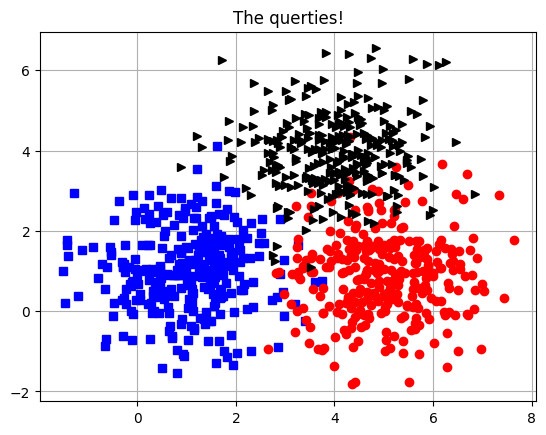

In [34]:
nPerClust = 300
blur = 1

A = [1, 1]
B = [5, 1]
C = [4, 4]

a = [A[0] + np.random.randn(nPerClust)*blur, A[1] + np.random.randn(nPerClust)*blur]
b = [B[0] + np.random.randn(nPerClust)*blur, B[1] + np.random.randn(nPerClust)*blur]
c = [C[0] + np.random.randn(nPerClust)*blur, C[1] + np.random.randn(nPerClust)*blur]

labelsNp = np.hstack((np.zeros(nPerClust), np.ones(nPerClust), 2*np.ones(nPerClust)))

data = torch.tensor(np.hstack((a, b, c)).T).float()
labels = torch.tensor(labelsNp).long()

trainData, testData, trainLabels, testLabels = train_test_split(data, labels, test_size=0.25)

trainData = TensorDataset(trainData, trainLabels)
testData = TensorDataset(testData, testLabels)

trainLoader = DataLoader(trainData, shuffle=True, batch_size=16, drop_last=True)
testLoader = DataLoader(testData, batch_size=testData.tensors[0].shape[0])

plt.plot(data[np.where(labels == 0)][:,0], data[np.where(labels == 0)][:,1], 'bs')
plt.plot(data[np.where(labels == 1)][:,0], data[np.where(labels == 1)][:,1], 'ro')
plt.plot(data[np.where(labels == 2)][:,0], data[np.where(labels == 2)][:,1], 'k>')
plt.grid()
plt.title('The querties!')
plt.show()

In [35]:
class quertyNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.input = nn.Linear(2, 4)

        self.hiddenLayers = [
            nn.Linear(4, 8),
            nn.Linear(8, 4)
        ]

        self.output = nn.Linear(4, 3)
    
    def forward(self, x):
        x = F.relu(self.input(x))
        for layer in self.hiddenLayers:
            x = F.relu(layer(x))
        return self.output(x)

In [44]:
def createAndTrainModel(momentum):
    model = quertyNet()

    numberOfEpochs = 1_000
    lossFunction = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=.01, momentum=momentum)

    trainingAccuracy = np.zeros(numberOfEpochs)
    testingAccuracy = np.zeros(numberOfEpochs)

    for epoch in range(numberOfEpochs):
        model.train()
        batchAccuracy = []

        for x,y in trainLoader:
            yHat = model(x)

            loss = lossFunction(yHat, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batchAccuracy.append(100*torch.mean((torch.argmax(yHat, axis=1) == y).float()))
        trainingAccuracy[epoch] = np.mean(batchAccuracy)

        model.eval()
        x,y = next(iter(testLoader))
        with torch.no_grad():
            yHat = model(x)
            testingAccuracy[epoch] = 100*torch.mean((torch.argmax(yHat, axis=1) == y).float())

    plt.plot(range(numberOfEpochs), trainingAccuracy, 'b-')
    plt.plot(range(numberOfEpochs), testAccuracy, 'g-')
    plt.grid()
    plt.legend(['Training accuracy', 'Test accuracy'])
    plt.xlabel('Training epochs')
    plt.ylabel('Accuracy (%)')
    plt.title(f'Momentum = {momentum}')
    plt.show()

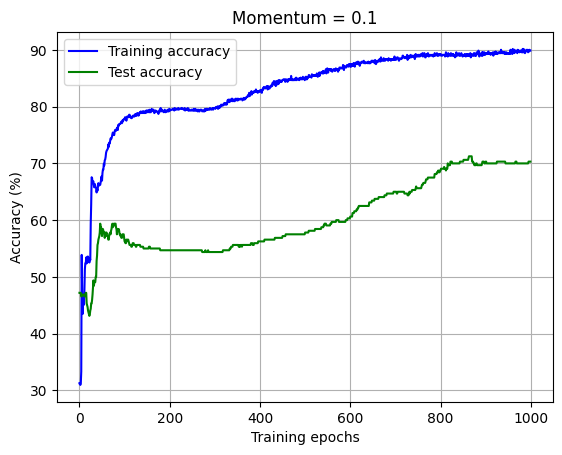

In [45]:
createAndTrainModel(0.1)

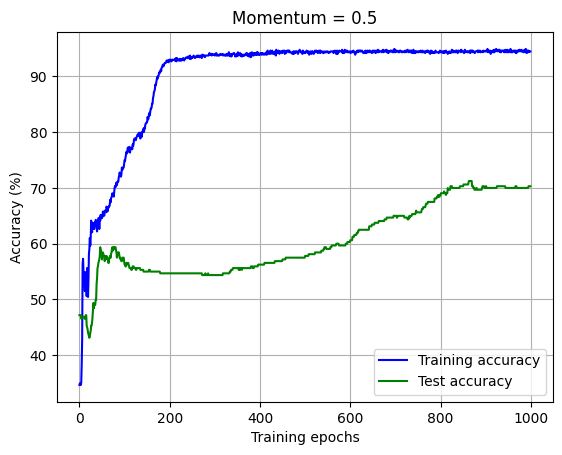

In [46]:
createAndTrainModel(0.5)

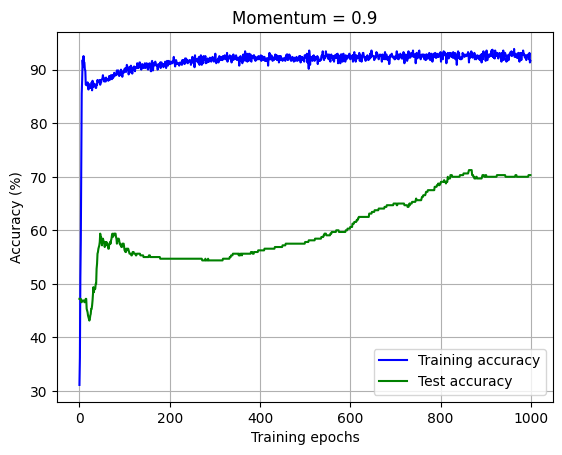

In [47]:
createAndTrainModel(0.9)

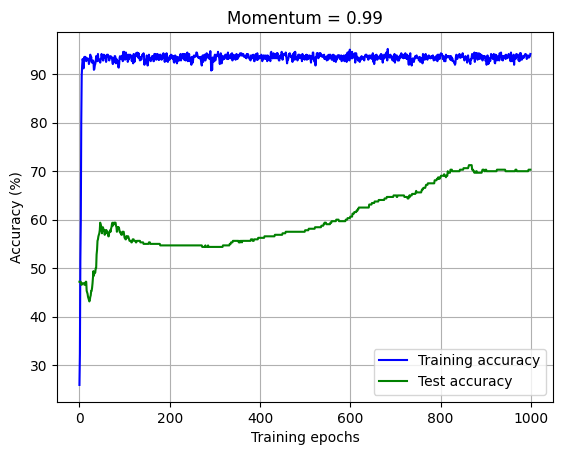

In [48]:
createAndTrainModel(0.99)

<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h2>RMSprop, Adam</h2>
<p>Both these algorithms are minor extensions of GD. RMSprop stands for Root Mean Square propagation. Adam is considered to be the best optimizer available right now.</p>

<p>RMSprop works by biasing the learningrate based on the gradient.</p>

<p>Adam stands for Adaptive momentum.</p>
</div>

<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h2>How to pick the right metaparameters?</h2>
<p><ul>
<li>Do what others have done with similar problems</li>
<li>Use knowledge from experience</li>
<li>Random search is more useful than grid search</li>
<li>Balance laziness and diligence</li>
</ul></p>
</div>